## 1 - Project Setup
This section initializes the complete workspace environment, mounts Google Drive and extracts the dataset from the .zip archive directly to the local instance storage (/content/dataset).


In [1]:
%pip install -q grad-cam timm seaborn

import os
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
import torch
import time
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import models, transforms
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score, confusion_matrix, roc_curve, auc
import timm
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.image import show_cam_on_image
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget
import random

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

Note: you may need to restart the kernel to use updated packages.


In [2]:
# Environment setup: works both on Colab (Drive-mounted) and on a local VM/JupyterLab.
try:
    from google.colab import drive
    drive.mount('/content/drive')
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

if IN_COLAB:
    DRIVE_ROOT = '/content/drive/MyDrive/internship-deepfake-forensic'
    DATASET_DIR = '/content/dataset'
    MODELS_DIR = os.path.join(DRIVE_ROOT, 'deepfake_models_final')

    if not os.path.exists(DATASET_DIR):
        print("Extracting the dataset... (this might take a few minutes)")
        !unzip -q {os.path.join(DRIVE_ROOT, 'deepfake_dataset.zip')} -d {DATASET_DIR}
        print("Extraction completed!")
    else:
        print("Dataset already present and ready to use!")
else:
    DATA_ROOT = '/home/lucia_pola/internship-deepfake-forensic/deepfake-forensics-pipeline/02_Extended_Framework'
    DATASET_DIR = os.path.join(DATA_ROOT, 'Datasets')
    MODELS_DIR = os.path.join(DATA_ROOT, 'deepfake_models_final')
    print(f"Running outside Colab. Using local paths under: {DATA_ROOT}")

os.makedirs(MODELS_DIR, exist_ok=True)
print(f"Dataset directory: {DATASET_DIR}")
print(f"Models directory:  {MODELS_DIR}")

Running outside Colab. Using local paths under: /home/lucia_pola/internship-deepfake-forensic/deepfake-forensics-pipeline/02_Extended_Framework
Dataset directory: /home/lucia_pola/internship-deepfake-forensic/deepfake-forensics-pipeline/02_Extended_Framework/Datasets
Models directory:  /home/lucia_pola/internship-deepfake-forensic/deepfake-forensics-pipeline/02_Extended_Framework/deepfake_models_final


## 2 - Dataset and Models Architecture


In [3]:
class DeepfakeDataset(Dataset):
    def __init__(self, real_dirs, fake_dirs, transform=None):
        self.filepaths, self.labels = [], []
        self.transform = transform
        extensions = ('*.png', '*.jpg', '*.jpeg', '*.PNG', '*.JPG', '*.JPEG')
        for d in real_dirs:
            for ext in extensions:
                paths = sorted(glob.glob(os.path.join(d, ext)))
                self.filepaths.extend(paths)
                self.labels.extend([0] * len(paths))
        for d in fake_dirs:
            for ext in extensions:
                paths = sorted(glob.glob(os.path.join(d, ext)))
                self.filepaths.extend(paths)
                self.labels.extend([1] * len(paths))

    def __len__(self): return len(self.filepaths)

    def __getitem__(self, idx):
        img = Image.open(self.filepaths[idx]).convert('RGB')
        if self.transform: img = self.transform(img)
        return img, torch.tensor([self.labels[idx]], dtype=torch.float32)


test_transforms = transforms.Compose([
    transforms.Resize((224, 224)), # Fail-safe resize
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

In [4]:
class StandardEfficientNet(nn.Module):
    def __init__(self, num_classes=1, pretrained=True):
        super().__init__()
        weights = models.EfficientNet_B0_Weights.DEFAULT if pretrained else None
        self.model = models.efficientnet_b0(weights=weights)
        in_features = self.model.classifier[1].in_features
        self.model.classifier = nn.Sequential(
            nn.Dropout(p=0.4, inplace=True),
            nn.Linear(in_features, num_classes)
        )

    def forward(self, x):
        return self.model(x)

class DeiT_Discriminator(nn.Module):
    def __init__(self, num_classes=1, pretrained=True):
        super().__init__()
        self.model = timm.create_model('deit_tiny_patch16_224', pretrained=pretrained)
        n_features = self.model.head.in_features
        self.model.head = nn.Linear(n_features, num_classes)

    def forward(self, x):
        return self.model(x)

class HybridDeepfakeDiscriminator(nn.Module):
    def __init__(self, num_classes=1, pretrained=True):
        super().__init__()
        weights = models.EfficientNet_B0_Weights.DEFAULT if pretrained else None
        self.backbone = models.efficientnet_b0(weights=weights).features
        in_channels = 1280
        self.attention = nn.Sequential(
            nn.Conv2d(in_channels, in_channels // 8, 1, bias=False),
            nn.BatchNorm2d(in_channels // 8), nn.ReLU(inplace=True),
            nn.Conv2d(in_channels // 8, in_channels, 1, bias=False), nn.Sigmoid()
        )
        self.pool = nn.AdaptiveAvgPool2d((1, 1))
        self.classifier = nn.Sequential(
            nn.Dropout(p=0.4), nn.Linear(in_channels, 256), nn.ReLU(inplace=True),
            nn.Dropout(p=0.4), nn.Linear(256, num_classes)
        )

    def forward(self, x):
        features = self.backbone(x)
        features = features * self.attention(features)
        return self.classifier(torch.flatten(self.pool(features), 1))

## 3 - Data Configuration

In [5]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device in use: {device}")

path_baseline = os.path.join(MODELS_DIR, 'baseline', 'path')
path_retrain  = os.path.join(MODELS_DIR, 'retrain', 'path')
BATCH = 32
NUM_WORKERS = 4

test_transforms = transforms.Compose([
    transforms.Resize((224, 224)), # Fail-safe resize
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

ts_reals = [f'{DATASET_DIR}/FEI_MORPHV2_DATASET/test/original/', f'{DATASET_DIR}/CELEBDFV3_DATASET/test/original/']
ts_fakes = [f'{DATASET_DIR}/FEI_MORPHV2_DATASET/test/fake/', f'{DATASET_DIR}/CELEBDFV3_DATASET/test/fake/']

# Test Dataloaders
test_loader = DataLoader(DeepfakeDataset(ts_reals, ts_fakes, test_transforms), BATCH, shuffle=False, num_workers=NUM_WORKERS)


Device in use: cuda


In [6]:
print("Loading Models for Direct Comparison...")

#Standard EfficientNet-B0
model_std_base = StandardEfficientNet(pretrained=False).to(device)
model_std_base.load_state_dict(torch.load(os.path.join(path_baseline, "std_b0_step1.pth"), map_location=device))

model_std_adv = StandardEfficientNet(pretrained=False).to(device)
model_std_adv.load_state_dict(torch.load(os.path.join(path_retrain, "std_b0_step2.pth"), map_location=device))

#Deit-Tiny
model_deit_base = DeiT_Discriminator(pretrained=False).to(device)
model_deit_base.load_state_dict(torch.load(os.path.join(path_baseline, "deit_step1.pth"), map_location=device))

model_deit_adv = DeiT_Discriminator(pretrained=False).to(device)
model_deit_adv.load_state_dict(torch.load(os.path.join(path_retrain, "deit_step2.pth"), map_location=device))

#Hybrid EfficientNet-B0
model_hyb_base = HybridDeepfakeDiscriminator(pretrained=False).to(device)
model_hyb_base.load_state_dict(torch.load(os.path.join(path_baseline, "hyb_b0_step1.pth"), map_location=device))

model_hyb_adv = HybridDeepfakeDiscriminator(pretrained=False).to(device)
model_hyb_adv.load_state_dict(torch.load(os.path.join(path_retrain, "hyb_b0_step2.pth"), map_location=device))

trained_models = {
    "Std EfficientNet-B0 (Step 1)": model_std_base,
    "Std EfficientNet-B0 (Step 2)": model_std_adv,
    "Deit-Tiny (Step 1)": model_deit_base,
    "Deit-Tiny (Step 2)": model_deit_adv,
    "Hyb EfficientNet-B0 (Step 1)": model_hyb_base,
    "Hyb EfficientNet-B0 (Step 2)": model_hyb_adv,
}

print("Models loaded and ready for the showdown!")

Loading Models for Direct Comparison...
Models loaded and ready for the showdown!


## 4 - Test Engine

In [7]:
def get_all_predictions(model, loader, device):
    model.eval()
    all_labels, all_probs, all_preds = [], [], []

    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)
            outputs = model(images).view(-1)

            probs = torch.sigmoid(outputs)
            preds = (outputs > 0.0).float()

            all_labels.extend(labels.view(-1).cpu().numpy())
            all_probs.extend(probs.cpu().numpy())
            all_preds.extend(preds.cpu().numpy())

    return np.array(all_labels), np.array(all_probs), np.array(all_preds)


def plot_final_evaluation(models_dict, loader, device, phase_name):
    print(f"\nStarting Quantitative Test for: {phase_name}")

    num_models = len(models_dict)
    fig, axes = plt.subplots(1, num_models + 1, figsize=(6 * (num_models + 1), 6))
    fig.suptitle(f"Quantitative Results - {phase_name}", fontsize=20, fontweight='bold')

    ax_roc = axes[-1]
    ax_roc.plot([0, 1], [0, 1], 'k--', label='Random')

    colors = ['#aec7e8', '#1f77b4', '#ffbb78', '#ff7f0e', '#98df8a', '#2ca02c']

    for i, (name, model) in enumerate(models_dict.items()):
        y_true, y_probs, y_preds = get_all_predictions(model, loader, device)

        # Metrics
        acc = accuracy_score(y_true, y_preds)
        f1 = f1_score(y_true, y_preds)
        prec = precision_score(y_true, y_preds)
        rec = recall_score(y_true, y_preds)

        print(f"[{name}] Acc: {acc:.4f} | F1: {f1:.4f} | Prec: {prec:.4f} | Rec: {rec:.4f}")

        # Confusion Matrix
        cm = confusion_matrix(y_true, y_preds)
        sns.heatmap(
            cm,
            annot=True,
            fmt='d',
            cmap='Blues',
            ax=axes[i],
            cbar=False,
            xticklabels=['REAL', 'FAKE'],
            yticklabels=['REAL', 'FAKE']
        )

        axes[i].set_title(f"{name}")
        if i == 0:
            axes[i].set_ylabel('Ground Truth')
        axes[i].set_xlabel('Predicted')

        # ROC Curve
        fpr, tpr, _ = roc_curve(y_true, y_probs)
        roc_auc = auc(fpr, tpr)

        ax_roc.plot(
            fpr,
            tpr,
            color=colors[i],
            lw=2.5,
            label=f"{name} (AUC: {roc_auc:.4f})"
        )

    ax_roc.set_title("ROC Curves")
    ax_roc.set_xlabel("False Positive Rate")
    ax_roc.set_ylabel("True Positive Rate")
    ax_roc.legend(loc="lower right", fontsize=9)

    plt.tight_layout()
    plt.show()

## 5 - Experimental Results

### 5.1 - Intra-Dataset Evaluation


Starting Quantitative Test for: Baseline vs Advanced
[Std EfficientNet-B0 (Step 1)] Acc: 0.9662 | F1: 0.9815 | Prec: 0.9975 | Rec: 0.9660
[Std EfficientNet-B0 (Step 2)] Acc: 0.8634 | F1: 0.9207 | Prec: 0.9989 | Rec: 0.8538
[Deit-Tiny (Step 1)] Acc: 0.7011 | F1: 0.8114 | Prec: 0.9783 | Rec: 0.6932
[Deit-Tiny (Step 2)] Acc: 0.7473 | F1: 0.8437 | Prec: 0.9903 | Rec: 0.7349
[Hyb EfficientNet-B0 (Step 1)] Acc: 0.9591 | F1: 0.9775 | Prec: 0.9985 | Rec: 0.9573
[Hyb EfficientNet-B0 (Step 2)] Acc: 0.8541 | F1: 0.9147 | Prec: 0.9994 | Rec: 0.8432


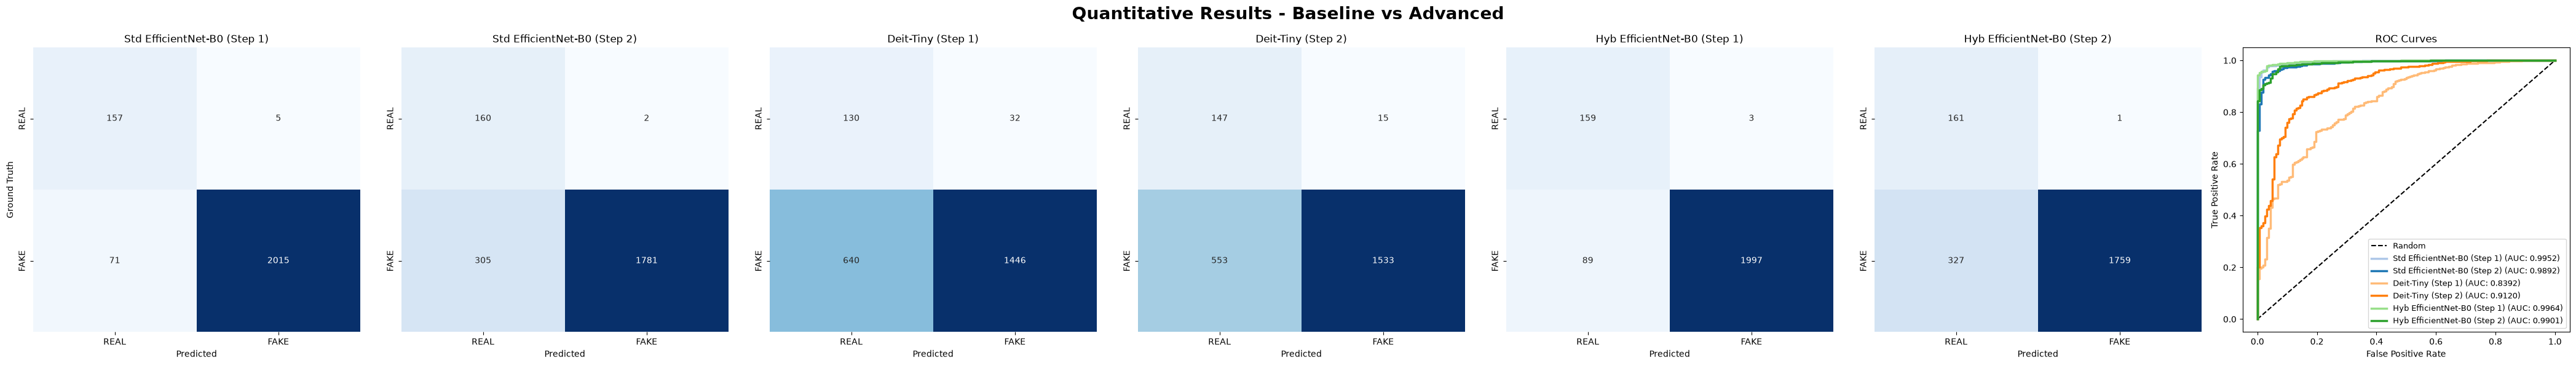

In [9]:
plot_final_evaluation(trained_models, test_loader, device, "Baseline vs Advanced")